In [1]:
import json
import logging
# import faster_coco_eval
from faster_coco_eval import COCO
from faster_coco_eval.extra import Curves
from faster_coco_eval.extra import PreviewResults
import matplotlib.pyplot as plt

print(f"{faster_coco_eval.__version__=}")

logging.root.setLevel("INFO")
logging.debug("Запись.")

ModuleNotFoundError: No module named 'faster_coco_eval'

In [ ]:
def load(file):
    with open(file) as io:
        _data = json.load(io)
        
    return _data

In [1]:
# Load the GT and prediction JSON files
gt_path = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Aerial_Seabirds_West_Africa/test.json'
pred_path = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Aerial_seabird_westafrica_od_dataset/prediction_mm_grounding_dino_nocaption.bbox.json'  # Replace with your prediction JSON path


In [ ]:
threshold_iou = 0.5
iouType = 'bbox'

cocoGt = COCO(gt_path)
cocoDt = cocoGt.loadRes(pred_path)

cur = Curves(cocoGt, cocoDt, iou_tresh=threshold_iou, iouType=iouType, useCats=True)
cur.plot_pre_rec(plotly_backend=True)

(Figure({
     'data': [{'hovertemplate': 'Pre: %{y:.3f}<br>Rec: %{x:.3f}<br>Score: %{text:.3f}<extra></extra>',
               'mode': 'lines',
               'name': 'auc: 0.003',
               'showlegend': True,
               'text': array([0.79211199, 0.59350389, 0.52216887, 0.38696983, 0.32101464, 0.18594453,
                              0.15155295, 0.12513378, 0.09503464, 0.06027323, 0.03509443, 0.        ,
                              0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
                              0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
                              0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
                              0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
                              0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
                              0.        , 0.        , 0.        , 0. 

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Loading and preparing results...
DONE (t=9.99s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.12s).
Accumulating evaluation results...
DONE (t=0.80s).


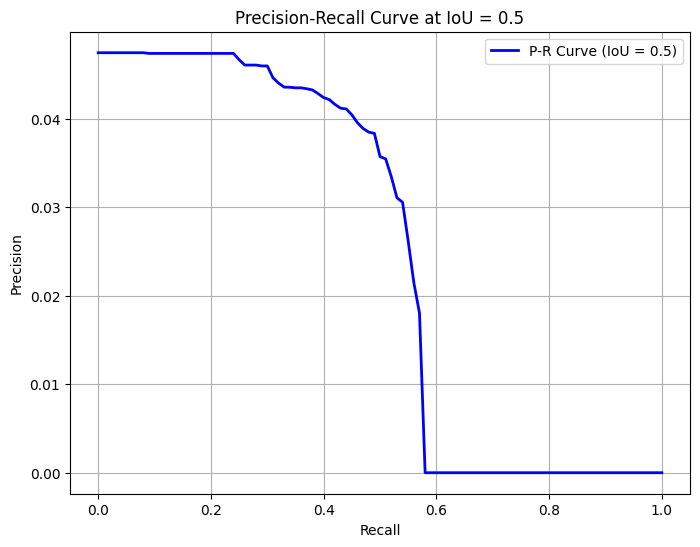

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Load the GT and prediction JSON files
gt_path = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json'  # Replace with your GT JSON path
pred_path = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino.bbox.json'  # Replace with your prediction JSON path

# Initialize COCO objects for GT and predictions
coco_gt = COCO(gt_path)
coco_pred = coco_gt.loadRes(pred_path)

# Initialize COCO evaluator
coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()


# Set the specific IoU threshold you want to use
desired_iou = 0.5  # Set your specific IoU threshold here
iou_thresholds = coco_eval.params.iouThrs
iou_index = np.where(np.isclose(iou_thresholds, desired_iou))[0][0]

# Extract precision and recall for the selected IoU threshold
precision_at_iou = coco_eval.eval['precision'][iou_index, :, 0, 0, 2]  # Averaging over categories and area
recall_at_iou = coco_eval.params.recThrs

# Plot P-R Curve at the specific IoU threshold
plt.figure(figsize=(8, 6))
plt.plot(recall_at_iou, precision_at_iou, label=f'P-R Curve (IoU = {desired_iou})', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve at IoU = {desired_iou}')
plt.legend(loc="upper right")
plt.grid()
plt.show()


In [2]:
coco_eval.summarize()

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.040
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.074
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.176
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.207
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np
import skimage.io as io
import pylab
pylab.rcParams['figure.figsize'] = (10.0, 8.0)

annType = ['segm','bbox','keypoints']
annType = annType[1]      #specify type here
prefix = 'person_keypoints' if annType=='keypoints' else 'instances'
# print 'Running demo for *%s* results.'%(annType)

#initialize COCO ground truth api
# dataDir='../'
# dataType='val2014'
annFile = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/Virunga_Garamba/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json'
cocoGt=COCO(annFile)

#initialize COCO detections api
# resFile='%s/results/%s_%s_fake%s100_results.json'
resFile = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/Virunga_garamba_dataset/prediction_mm_grounding_dino.bbox.json'
cocoDt=cocoGt.loadRes(resFile)

imgIds=sorted(cocoGt.getImgIds())
imgIds=imgIds[0:100]
imgId = imgIds[np.random.randint(100)]

# running evaluation
cocoEval = COCOeval(cocoGt,cocoDt,annType)
cocoEval.params.imgIds  = imgIds
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=6.75s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.85s).
Accumulating evaluation results...
DONE (t=0.24s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.061
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.07s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.51s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.006
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

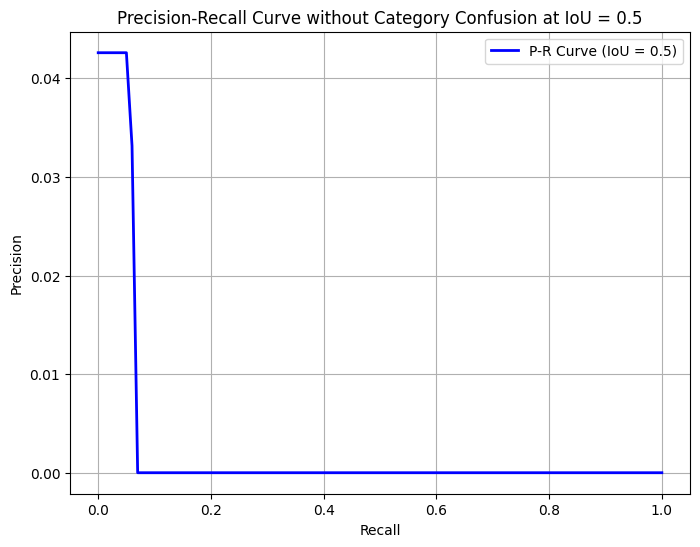

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import copy


# Load the GT and prediction JSON files
gt_path = '/home/m32patel/projects/rrg-dclausi/wildlife/datasets/birds_penguins/test_grounded.json'
pred_path = '/home/m32patel/projects/def-dclausi/whale/mmwhale2/work_dir_grounding_dino/penguins_od_dataset/prediction_mm_grounding_dino_nocaption.bbox.json'  # Replace with your prediction JSON path

# Load ground truth and prediction JSON
with open(gt_path, 'r') as f:
    gt_data = json.load(f)
with open(pred_path, 'r') as f:
    pred_data = json.load(f)

# Create copies and set category_id to 1 for all annotations and predictions
gt_data_no_confusion = copy.deepcopy(gt_data)
pred_data_no_confusion = copy.deepcopy(pred_data)

for ann in gt_data_no_confusion['annotations']:
    ann['category_id'] = 1  # Set all ground truth annotations to category 1

for ann in pred_data_no_confusion:
    ann['category_id'] = 1  # Set all prediction annotations to category 1

# Save modified JSON files
with open('gt_no_confusion.json', 'w') as f:
    json.dump(gt_data_no_confusion, f)
with open('pred_no_confusion.json', 'w') as f:
    json.dump(pred_data_no_confusion, f)

# Load the modified GT and prediction files in COCO
coco_gt = COCO('gt_no_confusion.json')
coco_pred = coco_gt.loadRes('pred_no_confusion.json')

# Initialize COCO evaluator
coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Set the IoU threshold you want to use for plotting
desired_iou = 0.5  # Adjust this IoU as needed
iou_thresholds = coco_eval.params.iouThrs
iou_index = np.where(np.isclose(iou_thresholds, desired_iou))[0][0]

# Extract precision and recall for the selected IoU threshold
precision_at_iou = coco_eval.eval['precision'][iou_index, :, 0, 0, 2]  # Averaging over categories and area
recall_at_iou = coco_eval.params.recThrs

# Plot P-R Curve at the specific IoU threshold
plt.figure(figsize=(8, 6))
plt.plot(recall_at_iou, precision_at_iou, label=f'P-R Curve (IoU = {desired_iou})', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve without Category Confusion at IoU = {desired_iou}')
plt.legend(loc="upper right")
plt.grid()
plt.show()
